# Setup & Data Loading

## Notes from Discussion section:
### **Transaction Table**

* **TransactionDT**: timedelta from a given reference datetime (not an actual timestamp)
* **TransactionAMT**: transaction payment amount in USD
* **ProductCD**: product code, the product for each transaction
* **card1 - card6**: payment card information, such as card type, card category, issue bank, country, etc.
* **addr**: address
* **dist**: distance
* **P_ and (R__) emaildomain**: purchaser and recipient email domain
* **C1-C14**: counting, such as how many addresses are found to be associated withthe  payment card, etc. The actual meaning is masked.
* **D1-D15**: timedelta, such as days between previous transaction, etc.
* **M1-M9**: match, such as names on card and address, etc.
* **Vxxx**: Vesta engineered rich features, including ranking, counting, and other entity relations.
* **Categorical Features**: ProductCD card1 - card6 addr1, addr2 P_emaildomain R_emaildomain M1 - M9


### **Identity Table**
* **Variables** in this table are identity information – network connection information (IP, ISP, Proxy, etc) and digital signature (UA/browser/os/version, etc) associated with transactions. They're collected by Vesta’s fraud protection system and digital security partners. (The field names are masked and pairwise dictionary will not be provided for privacy protection and contract agreement)

* **Categorical Features**: DeviceType DeviceInfo id_12 - id_38

In [1]:
# ── Imports ──
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', 100)
sns.set_style('whitegrid')
%matplotlib inline

In [2]:
# ── Get data via Kaggle API ──
from google.colab import files
files.upload()  # select kaggle.json

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle competitions download -c ieee-fraud-detection
!unzip -q ieee-fraud-detection.zip -d data/

Saving kaggle.json to kaggle.json
100% 118M/118M [00:01<00:00, 88.4MB/s]



In [3]:
# ── Load & merge tables ──
# Dataset comes as two files per split, joined on TransactionID
train_tx = pd.read_csv('data/train_transaction.csv')
train_id = pd.read_csv('data/train_identity.csv')

test_tx = pd.read_csv('data/test_transaction.csv')
test_id = pd.read_csv('data/test_identity.csv')

train = train_tx.merge(train_id, on='TransactionID', how='left')
test = test_tx.merge(test_id, on='TransactionID', how='left')

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
del train_tx, train_id, test_tx, test_id  # free memory

Train shape: (590540, 434)
Test shape: (506691, 433)


# Initial Exploration

In [22]:
# ── Standardize column names (fixes train vs test hyphen discrepancy: id-01 -> id_01) ──
train.columns = [c.replace('-', '_') for c in train.columns]
test.columns  = [c.replace('-', '_') for c in test.columns]

# ── Identify feature groups strictly ──
id_cols   = [c for c in train.columns if c.startswith('id_')]
c_cols    = [c for c in train.columns if c.startswith('C') and c[1:].isdigit()]
d_cols    = [c for c in train.columns if c.startswith('D') and c[1:].isdigit()]
m_cols    = [c for c in train.columns if c.startswith('M') and c[1:].isdigit()]
v_cols    = [c for c in train.columns if c.startswith('V') and c[1:].isdigit()]
card_cols = [c for c in train.columns if c.startswith('card')]

print(f"id_ cols:            {len(id_cols)} (Expected: 38)")
print(f"C cols (counting):    {len(c_cols)} (Expected: 14)")
print(f"D cols (time deltas): {len(d_cols)} (Expected: 15)")
print(f"M cols (match flags): {len(m_cols)} (Expected: 9)")
print(f"V cols (engineered):  {len(v_cols)} (Expected: 339)")
print(f"card cols:           {len(card_cols)} (Expected: 6)")

id_ cols:            38 (Expected: 38)
C cols (counting):    14 (Expected: 14)
D cols (time deltas): 15 (Expected: 15)
M cols (match flags): 9 (Expected: 9)
V cols (engineered):  339 (Expected: 339)
card cols:           6 (Expected: 6)


In [4]:
# ── First look ──
train.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,M0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,87.0,287.0,NaN,outlook.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,315.0,NaN,NaN,NaN,315.0,T,T,T,M0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,87.0,NaN,NaN,yahoo.com,NaN,2.0,5.0,0.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,1.0,0.0,25.0,1.0,112.0,112.0,0.0,94.0,0.0,NaN,NaN,NaN,NaN,84.0,NaN,NaN,NaN,NaN,111.0,NaN,NaN,NaN,M0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,credit,420.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,NotFound,NaN,-480.0,New,NotFound,166.0,NaN,542.0,144.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,Android 7.0,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [14]:
# ── First look ──
train.tail()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,...,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo,DT_day
590535,3577535,0,15811047,49.00,W,6550,NaN,150.0,visa,226.0,debit,272.0,87.0,48.0,NaN,NaN,NaN,2.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0,0.0,1.0,0.0,3.0,2.0,29.0,29.0,30.0,NaN,NaN,NaN,NaN,NaN,NaN,56.0,56.0,NaN,NaN,NaN,56.0,T,T,T,M0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,182
590536,3577536,0,15811049,39.50,W,10444,225.0,150.0,mastercard,224.0,debit,204.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0,T,F,F,M0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,182
590537,3577537,0,15811079,30.95,W,12037,595.0,150.0,mastercard,224.0,debit,231.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0,T,F,F,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,182
590538,3577538,0,15811088,117.00,W,7826,481.0,150.0,mastercard,224.0,debit,387.0,87.0,3.0,NaN,aol.com,NaN,1.0,1.0,0.0,0.0,0.0,3.0,0.0,0.0,2.0,0.0,1.0,1.0,5.0,1.0,22.0,22.0,0.0,22.0,0.0,NaN,NaN,NaN,NaN,22.0,22.0,NaN,NaN,NaN,22.0,T,T,T,M0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,182
590539,3577539,0,15811131,279.95,W,15066,170.0,150.0,mastercard,102.0,credit,299.0,87.0,NaN,NaN,gmail.com,NaN,2.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,2.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,0.0,1.0,0.0,NaN,NaN,NaN,NaN,1.0,0.0,NaN,NaN,NaN,1.0,T,F,F,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,182


In [5]:
# ── Dtypes & memory footprint ──
train.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: float64(399), int64(4), object(31)
memory usage: 2.5 GB


Fraud rate: 3.4990%


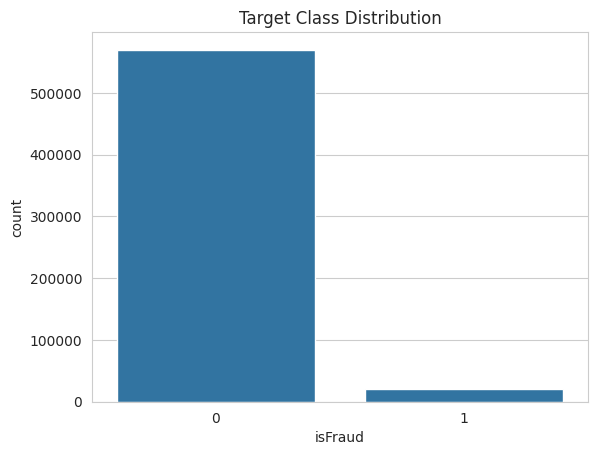

In [6]:
# ── Target distribution (class imbalance here) ──
fraud_rate = train['isFraud'].mean()
print(f"Fraud rate: {fraud_rate:.4%}")

sns.countplot(x='isFraud', data=train)
plt.title('Target Class Distribution')
plt.show()

Columns with missing values: 414 / 434


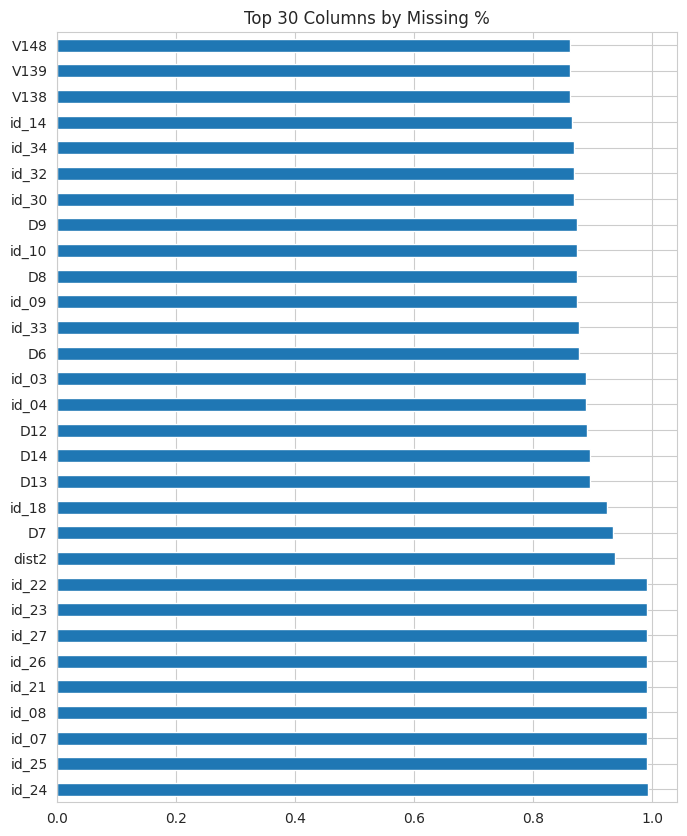

In [7]:
# ── Missing values ──
missing = train.isnull().mean().sort_values(ascending=False)
missing = missing[missing > 0]
print(f"Columns with missing values: {len(missing)} / {train.shape[1]}")
missing.head(30).plot(kind='barh', figsize=(8,10))
plt.title('Top 30 Columns by Missing %')
plt.show()

### Numerical Data Analysis

In [15]:
# ── Numerical Summary Generator ──
def get_numerical_summary(df, cols=None, percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]):
    """
    Calculates summary statistics (mean, std, min, percentiles, max)
    and missing values for numeric columns.
    """
    if cols is None:
        cols = df.select_dtypes(include=['number']).columns.tolist()

    desc = df[cols].describe(percentiles=percentiles).T

    # Calculate missing values
    desc['missing_count'] = df[cols].isnull().sum()
    desc['missing_pct'] = (desc['missing_count'] / len(df)) * 100

    # Reorder columns cleanly
    percentile_cols = [f'{int(p*100)}%' for p in percentiles]
    cols_order = ['count', 'missing_pct', 'mean', 'std', 'min'] + percentile_cols + ['max']

    return desc[cols_order]

In [16]:
# ── Summarize Core Numerical & Delta Features ──
core_num_cols = ['TransactionAmt'] + c_cols + d_cols

print("=== Core Features (TransactionAmt, C-cols, D-cols) ===")
core_summary = get_numerical_summary(train, cols=core_num_cols)
core_summary.sort_values(by='missing_pct')

=== Core Features (TransactionAmt, C-cols, D-cols) ===


,count,missing_pct,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
TransactionAmt,590540.0,0.000000,135.027176,239.162522,0.251,9.244,20.000,43.321000,68.769000,125.000000,445.000000,1104.000000,31937.391000
C1,590540.0,0.000000,14.092458,133.569018,0.000,1.000,1.000,1.000000,1.000000,3.000000,22.000000,164.000000,4685.000000
C2,590540.0,0.000000,15.269734,154.668899,0.000,1.000,1.000,1.000000,1.000000,3.000000,27.000000,154.000000,5691.000000
C3,590540.0,0.000000,0.005644,0.150536,0.000,0.000,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,26.000000
C4,590540.0,0.000000,4.092185,68.848459,0.000,0.000,0.000,0.000000,0.000000,0.000000,1.000000,6.000000,2253.000000
C5,590540.0,0.000000,5.571526,25.786976,0.000,0.000,0.000,0.000000,0.000000,1.000000,9.000000,149.000000,349.000000
C6,590540.0,0.000000,9.071082,71.508467,0.000,0.000,0.000,1.000000,1.000000,2.000000,15.000000,118.000000,2253.000000
C7,590540.0,0.000000,2.848478,61.727304,0.000,0.000,0.000,0.000000,0.000000,0.000000,1.000000,4.000000,2255.000000
C8,590540.0,0.000000,5.144574,95.378574,0.000,0.000,0.000,0.000000,0.000000,0.000000,2.000000,11.000000,3331.000000
C9,590540.0,0.000000,4.480240,16.674897,0.000,0.000,0.000,0.000000,1.000000,2.000000,9.000000,95.000000,210.000000


In [17]:
# ── Compare TransactionAmt & Counts by Fraud Status ──
print("=== Legitimate Transactions (isFraud = 0) ===")
display(get_numerical_summary(train[train['isFraud'] == 0], cols=['TransactionAmt'] + c_cols[:5]))

print("\n=== Fraudulent Transactions (isFraud = 1) ===")
display(get_numerical_summary(train[train['isFraud'] == 1], cols=['TransactionAmt'] + c_cols[:5]))

=== Legitimate Transactions (isFraud = 0) ===


,count,missing_pct,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
TransactionAmt,569877.0,0.0,134.511665,239.395078,0.251,9.51288,20.7298,43.97,68.5,120.0,435.0,1104.0,31937.391
C1,569877.0,0.0,13.314952,127.787969,0.000,1.00000,1.0000,1.00,1.0,3.0,18.0,159.0,4685.000
C2,569877.0,0.0,14.173283,147.485925,0.000,1.00000,1.0000,1.00,1.0,3.0,20.0,148.0,5691.000
C3,569877.0,0.0,0.005840,0.153208,0.000,0.00000,0.0000,0.00,0.0,0.0,0.0,0.0,26.000
C4,569877.0,0.0,3.693878,65.839255,0.000,0.00000,0.0000,0.00,0.0,0.0,1.0,3.0,2253.000
C5,569877.0,0.0,5.722537,26.121841,0.000,0.00000,0.0000,0.00,0.0,1.0,10.0,150.0,349.000



=== Fraudulent Transactions (isFraud = 1) ===


,count,missing_pct,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
TransactionAmt,20663.0,0.0,149.244779,232.212163,0.292,6.74096,13.0626,35.044,75.0,161.0,500.0,994.00,5191.0
C1,20663.0,0.0,35.535740,242.976260,0.000,1.00000,1.0000,1.000,2.0,6.0,117.0,510.38,4682.0
C2,20663.0,0.0,45.509413,287.813648,0.000,1.00000,1.0000,1.000,2.0,7.0,126.0,876.38,5690.0
C3,20663.0,0.0,0.000242,0.015554,0.000,0.00000,0.0000,0.000,0.0,0.0,0.0,0.00,1.0
C4,20663.0,0.0,15.077336,125.673738,0.000,0.00000,0.0000,0.000,1.0,2.0,21.0,206.04,2251.0
C5,20663.0,0.0,1.406717,12.946092,0.000,0.00000,0.0000,0.000,0.0,0.0,1.0,26.00,331.0


In [18]:
from scipy.stats import ks_2samp

def rank_feature_differences(df, target_col='isFraud', cols=None):
    """
    Ranks numerical features based on their separation capability
    between target classes using KS-Statistic and Cohen's d.
    """
    if cols is None:
        cols = df.select_dtypes(include=['number']).columns.drop(target_col).tolist()

    legit = df[df[target_col] == 0]
    fraud = df[df[target_col] == 1]

    results = []

    for col in cols:
        s_legit = legit[col].dropna()
        s_fraud = fraud[col].dropna()

        # Skip empty columns
        if len(s_legit) == 0 or len(s_fraud) == 0:
            continue

        m0, m1 = s_legit.mean(), s_fraud.mean()
        std0, std1 = s_legit.std(), s_fraud.std()

        # 1. Standardized Mean Difference (Cohen's d)
        pooled_std = np.sqrt((std0**2 + std1**2) / 2)
        cohens_d = (m1 - m0) / pooled_std if pooled_std > 0 else 0

        # 2. Kolmogorov-Smirnov (KS) Statistic
        ks_stat = ks_2samp(s_legit, s_fraud).statistic

        # 3. Mean Multiplier Ratio
        mean_ratio = (m1 + 1e-5) / (m0 + 1e-5)

        results.append({
            'Feature': col,
            'Legit_Mean': m0,
            'Fraud_Mean': m1,
            'Mean_Ratio (Fraud/Legit)': mean_ratio,
            'Cohens_d': cohens_d,
            'Abs_Cohens_d': abs(cohens_d),
            'KS_Statistic': ks_stat
        })

    res_df = pd.DataFrame(results).sort_values(by='KS_Statistic', ascending=False).reset_index(drop=True)
    return res_df

In [19]:
# Evaluate core features and C-cols
ranked_c_cols = rank_feature_differences(train, cols=['TransactionAmt'] + c_cols)

# visual gradient highlighting
ranked_c_cols.style.background_gradient(subset=['KS_Statistic', 'Abs_Cohens_d'], cmap='OrRd')

,Feature,Legit_Mean,Fraud_Mean,Mean_Ratio (Fraud/Legit),Cohens_d,Abs_Cohens_d,KS_Statistic
0,C4,3.693878,15.077336,4.081701,0.113470,0.113470,0.330962
1,C8,4.560881,21.242608,4.657559,0.118692,0.118692,0.316343
2,C10,4.723526,19.493926,4.126979,0.104936,0.104936,0.311933
3,C12,3.549703,18.597541,5.239171,0.116981,0.116981,0.296694
4,C9,4.580904,1.703964,0.371972,-0.215421,0.215421,0.292127
5,C5,5.722537,1.406717,0.245822,-0.209354,0.209354,0.287236
6,C7,2.517484,11.977157,4.757576,0.103452,0.103452,0.278473
7,C2,14.173283,45.509413,3.210928,0.137031,0.137031,0.204344
8,C14,8.220491,10.356047,1.259784,0.031543,0.031543,0.198406
9,C13,32.814474,24.967768,0.760877,-0.052969,0.052969,0.188578


In [27]:
# Evaluate all D-features
ranked_d_cols = rank_feature_differences(train, cols=d_cols)
print("=== Top Most Discriminative D-Features ===")
ranked_d_cols.style.background_gradient(subset=['KS_Statistic', 'Abs_Cohens_d'], cmap='OrRd')

=== Top Most Discriminative D-Features ===


,Feature,Legit_Mean,Fraud_Mean,Mean_Ratio (Fraud/Legit),Cohens_d,Abs_Cohens_d,KS_Statistic
0,D5,43.491155,13.687776,0.314726,-0.405757,0.405757,0.437124
1,D3,28.845357,11.744880,0.407167,-0.319983,0.319983,0.361771
2,D2,171.956223,77.774206,0.452291,-0.606890,0.606890,0.324828
3,D8,157.343727,49.309191,0.313385,-0.560151,0.560151,0.313902
4,D7,46.943007,11.292228,0.240552,-0.437151,0.437151,0.269363
5,D10,126.396130,52.363653,0.414282,-0.468731,0.468731,0.262445
6,D15,166.633142,78.245805,0.469569,-0.492021,0.492021,0.248453
7,D1,96.364705,38.711306,0.401717,-0.433004,0.433004,0.210358
8,D4,142.432339,72.102904,0.506226,-0.417585,0.417585,0.194635
9,D11,147.808201,87.314445,0.590728,-0.360609,0.360609,0.159335


In [28]:
# Evaluate top V-features (out of 339)
ranked_v_cols = rank_feature_differences(train, cols=v_cols)
print("\n=== Top Most Discriminative V-Features ===")
ranked_v_cols.style.background_gradient(subset=['KS_Statistic', 'Abs_Cohens_d'], cmap='OrRd')


=== Top Most Discriminative V-Features ===


,Feature,Legit_Mean,Fraud_Mean,Mean_Ratio (Fraud/Legit),Cohens_d,Abs_Cohens_d,KS_Statistic
0,V258,1.169115,3.400903,2.908939,0.665439,0.665439,0.462110
1,V257,1.106015,2.961342,2.677474,0.663187,0.663187,0.435966
2,V265,146.871712,231.958628,1.579328,0.069600,0.069600,0.417879
3,V219,1.205684,3.271782,2.713618,0.215683,0.215683,0.417817
4,V264,195.432737,275.094347,1.407616,0.046212,0.046212,0.415084
5,V218,1.533018,3.999902,2.609158,0.219305,0.219305,0.414007
6,V274,101.464798,174.240926,1.717255,0.075750,0.075750,0.410702
7,V232,0.839310,2.967327,3.535405,0.244896,0.244896,0.410702
8,V246,1.072598,2.494702,2.325838,0.635067,0.635067,0.403242
9,V263,111.837490,182.903241,1.635438,0.071942,0.071942,0.397383


### Feature Separation Diagnostics: KS Statistic vs. Cohen's d

When evaluating continuous and count features across fraudulent ($y=1$) and legitimate ($y=0$) transactions, we compute two distinct statistical metrics:

---

#### 1. Metric Definitions

* **Kolmogorov-Smirnov (KS) Statistic**:
  Measures the maximum vertical distance between the cumulative distribution functions (CDFs) of the two classes.
  $$\text{KS} = \sup_{x} \vert{}F_{\text{legit}}(x) - F_{\text{fraud}}(x)\vert{}$$
  * **Scale:** $0.0$ (identical distributions) to $1.0$ (perfect separation).
  * **Properties:** Non-parametric. It evaluates the overall shape of the distribution rather than summary statistics.

* **Cohen's $d$ (Standardized Mean Difference)**:
  Measures the distance between class means expressed in units of standard deviation.
  $$d = \frac{\mu_{\text{fraud}} - \mu_{\text{legit}}}{\sigma_{\text{pooled}}}, \quad \text{where } \sigma_{\text{pooled}} = \sqrt{\frac{\sigma_{\text{legit}}^2 + \sigma_{\text{fraud}}^2}{2}}$$
  * **Properties:** Parametric. Relies heavily on the assumption that distributions are symmetric and normally distributed.

---

#### 2. Primary Focus: Why Prioritize `KS_Statistic`?

For the IEEE-CIS dataset, primary focus should be placed on **`KS_Statistic`** rather than Cohen's $d$ for two main reasons:

1. **Robustness to Extreme Outliers:**  
   Financial features (such as `TransactionAmt`, `C1`–`C14`, and `D1`–`D15`) contain heavy right-tail skewness and large extreme values. Outliers drastically inflate the pooled standard deviation ($\sigma_{\text{pooled}}$), causing Cohen's $d$ to shrink close to $0$ even when a genuine separation exists across $99\%$ of the data. `KS_Statistic` is rank-based and immune to outlier magnitude.
2. **Handling Zero-Inflation:**  
   Many features contain over $80\%$ zero values followed by intermittent spikes. A simple mean ($\mu$) fails to capture this structure, whereas `KS_Statistic` correctly measures the shift in cumulative probabilities.

---

#### 3. Feature Interpretation Guidelines

* **$\text{KS} > 0.40$**: High-impact feature. Excellent separation power on its own (common in top `V` and `C` features).
* **$\text{KS} \in [0.20, 0.40]$**: Strong feature. Provides high utility for decision trees and neural network embeddings.
* **$\text{KS} < 0.05$**: Weak standalone separator. Requires feature interactions or non-linear combinations to provide signal.
* **High KS ($> 0.30$) + Low Cohen's $d$ ($< 0.10$)**: Indicates severe skewness and heavy tails. These features require log transformations (e.g., `np.log1p`) or quantile scaling before feeding into PyTorch neural networks.


**Notes**: this output was produced with the help from Gemini to correctly point out mathematical side.

*The prompt is: "Tell me again what is the difference between 'KS_Statistic', 'Abs_Cohens_d', and where should I put more attention? Write it in a short and concise format."*

### Categorical Data Analysis

In [29]:
def analyze_categorical(df, col, target='isFraud'):
    """Calculates distribution and fraud rate for a categorical column."""
    stats = pd.DataFrame({
        'Count': df[col].value_counts(dropna=False),
        'Share (%)': df[col].value_counts(normalize=True, dropna=False) * 100,
        'Fraud Rate (%)': df.groupby(col, dropna=False)[target].mean() * 100
    })
    return stats.sort_values(by='Count', ascending=False)

In [30]:
print("=== Card Network (card4) ===")
analyze_categorical(train, 'card4')

=== Card Network (card4) ===


,Count,Share (%),Fraud Rate (%)
card4,,,
visa,384767,65.155112,3.475610
mastercard,189217,32.041352,3.433095
american express,8328,1.410235,2.869837
discover,6651,1.126257,7.728161
NaN,1577,0.267044,2.599873


In [31]:
print("\n=== Card Type (card6) ===")
analyze_categorical(train, 'card6')


=== Card Type (card6) ===


,Count,Share (%),Fraud Rate (%)
card6,,,
debit,439938,74.497578,2.426251
credit,148986,25.228774,6.678480
NaN,1571,0.266028,2.482495
debit or credit,30,0.005080,0.000000
charge card,15,0.002540,0.000000


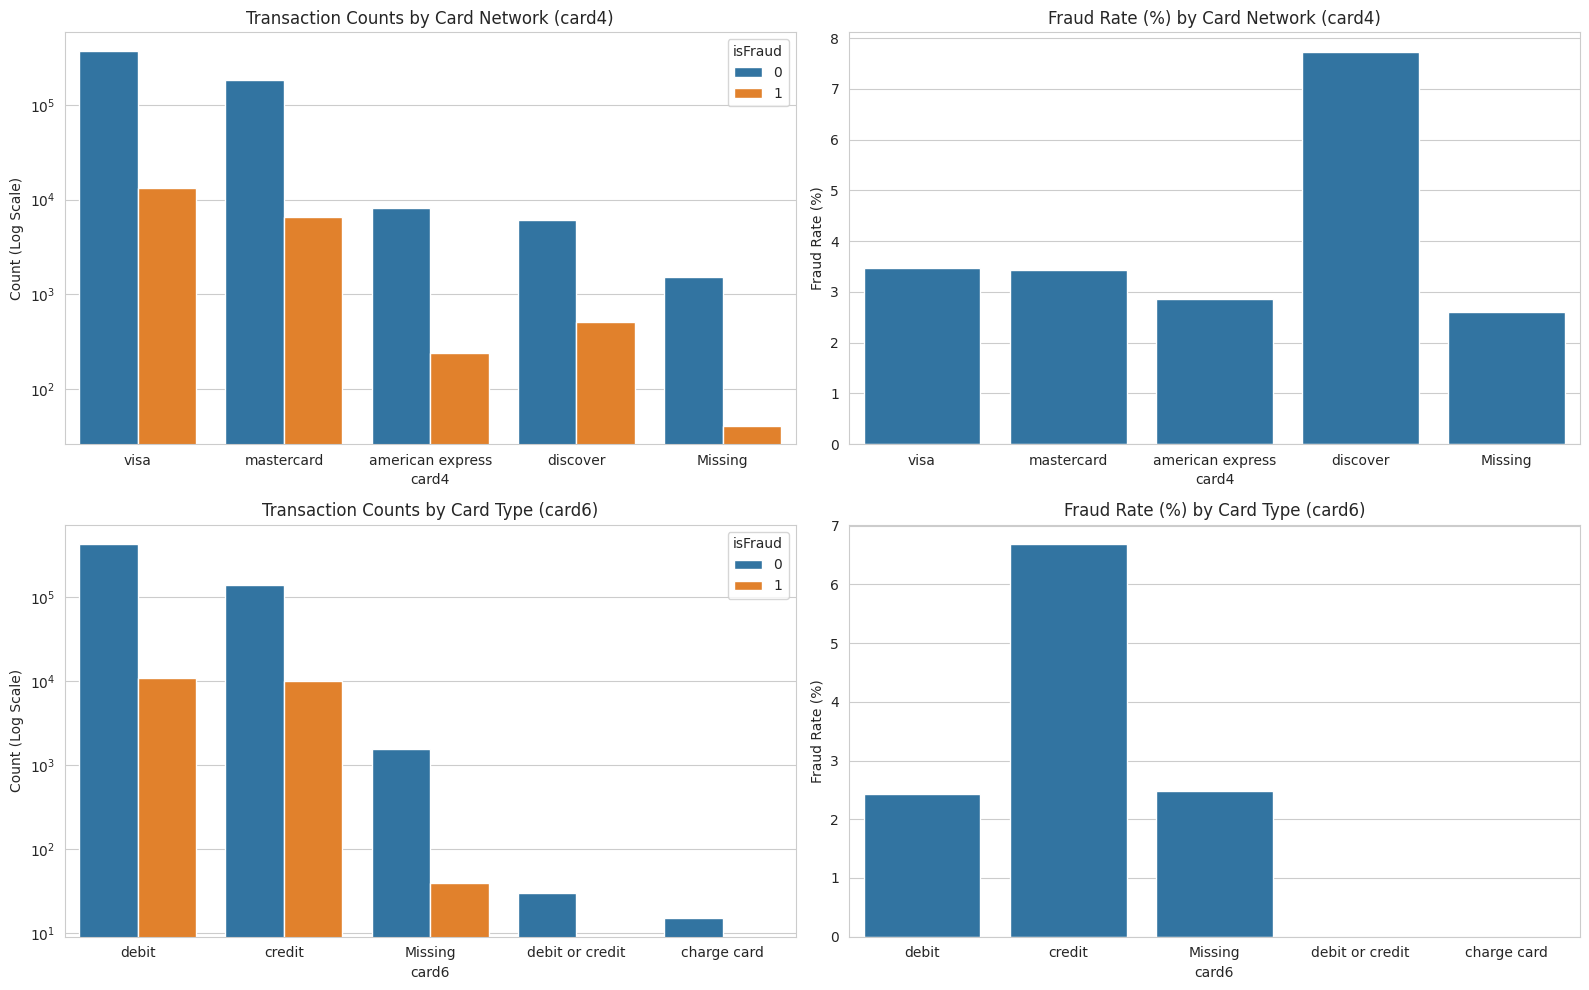

In [34]:
# ── Visualizing Distributions: Legit vs Fraud (Including Missing Values) ──
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Create temporary copies with explicit 'Missing' string labels
card4_clean = train['card4'].fillna('Missing')
card6_clean = train['card6'].fillna('Missing')

# Order categories including 'Missing'
card4_order = card4_clean.value_counts().index
card6_order = card6_clean.value_counts().index

# card4: Total Count by Fraud Status
sns.countplot(x=card4_clean, hue=train['isFraud'], ax=axes[0, 0], order=card4_order)
axes[0, 0].set_title('Transaction Counts by Card Network (card4)')
axes[0, 0].set_yscale('log')
axes[0, 0].set_ylabel('Count (Log Scale)')
axes[0, 0].set_xlabel('card4')

# card4: Fraud Rate
card4_fraud = train.groupby(card4_clean)['isFraud'].mean() * 100
sns.barplot(x=card4_fraud.index, y=card4_fraud.values, ax=axes[0, 1], order=card4_order)
axes[0, 1].set_title('Fraud Rate (%) by Card Network (card4)')
axes[0, 1].set_ylabel('Fraud Rate (%)')
axes[0, 1].set_xlabel('card4')

# card6: Total Count by Fraud Status
sns.countplot(x=card6_clean, hue=train['isFraud'], ax=axes[1, 0], order=card6_order)
axes[1, 0].set_title('Transaction Counts by Card Type (card6)')
axes[1, 0].set_yscale('log')
axes[1, 0].set_ylabel('Count (Log Scale)')
axes[1, 0].set_xlabel('card6')

# card6: Fraud Rate
card6_fraud = train.groupby(card6_clean)['isFraud'].mean() * 100
sns.barplot(x=card6_fraud.index, y=card6_fraud.values, ax=axes[1, 1], order=card6_order)
axes[1, 1].set_title('Fraud Rate (%) by Card Type (card6)')
axes[1, 1].set_ylabel('Fraud Rate (%)')
axes[1, 1].set_xlabel('card6')

plt.tight_layout()
plt.show()

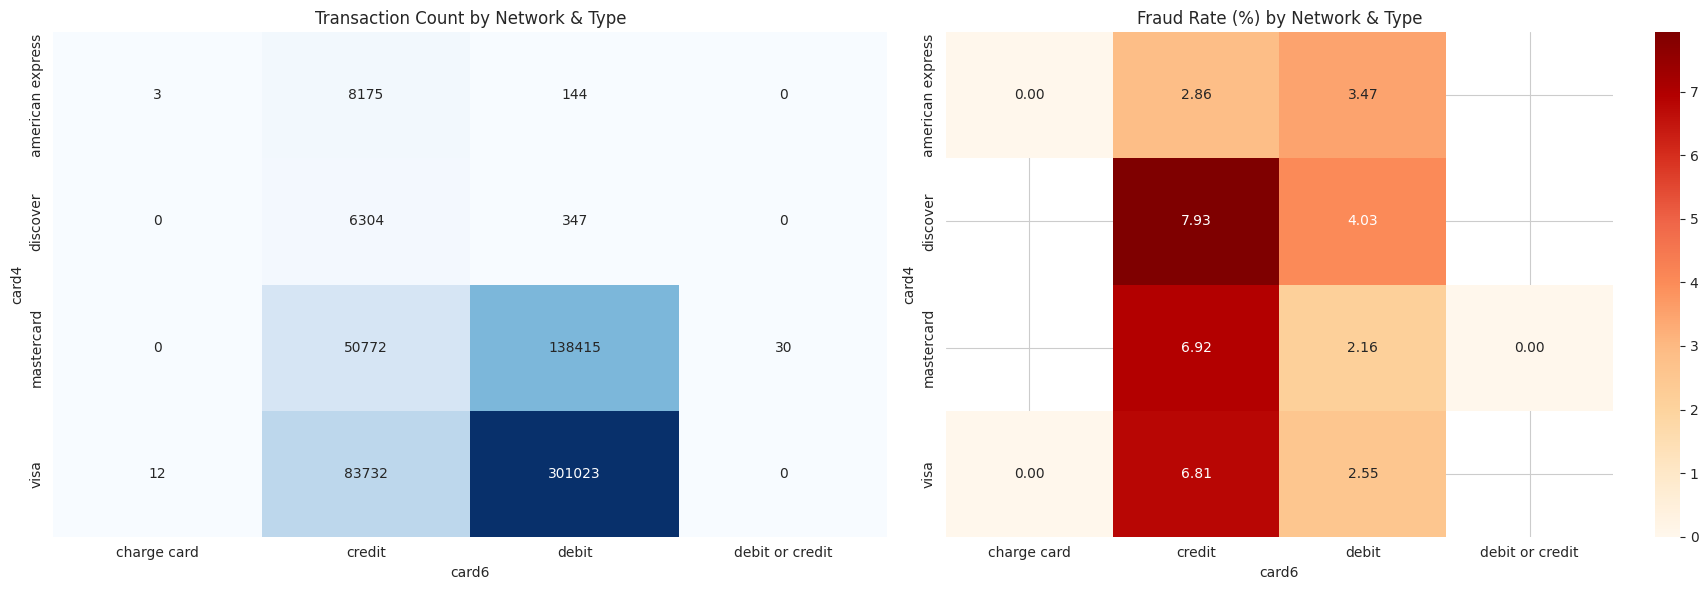

In [33]:
# ── Cross-Tabulation: Fraud Rate by Network and Type ──
# Calculate mean fraud rate for the combinations
crosstab_fraud = pd.crosstab(train['card4'], train['card6'], values=train['isFraud'], aggfunc='mean') * 100
# Calculate transaction volume for the combinations
crosstab_count = pd.crosstab(train['card4'], train['card6'])

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Heatmap for transaction counts
sns.heatmap(crosstab_count, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Transaction Count by Network & Type')

# Heatmap for fraud rates
sns.heatmap(crosstab_fraud, annot=True, fmt='.2f', cmap='OrRd', ax=axes[1])
axes[1].set_title('Fraud Rate (%) by Network & Type')

plt.tight_layout()
plt.show()

In [35]:
# ── Modular Visualizer for Categorical Features ──
def plot_categorical_feature(df, col, top_n=15, target='isFraud'):
    """
    Plots transaction count (log scale) and fraud rate (%) for the top N categories,
    including missing values.
    """
    # Copy series and handle NaNs
    s = df[col].astype(str).fillna('Missing')
    s = s.replace({'nan': 'Missing'})

    # Identify top N categories by volume
    top_cats = s.value_counts().head(top_n).index.tolist()

    # Filter dataframe view to top categories
    mask = s.isin(top_cats)
    filtered_s = s[mask]
    filtered_target = df.loc[mask, target]

    # Compute stats
    counts = filtered_s.value_counts()[top_cats]
    fraud_rates = filtered_target.groupby(filtered_s).mean()[top_cats] * 100

    # Plotting
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Plot 1: Volume (Log Scale)
    sns.barplot(x=counts.index, y=counts.values, ax=axes[0], color='skyblue')
    axes[0].set_title(f'Top {top_n} Categories by Count: {col}')
    axes[0].set_yscale('log')
    axes[0].set_ylabel('Transaction Count (Log Scale)')
    axes[0].tick_params(axis='x', rotation=45)

    # Plot 2: Fraud Rate (%)
    sns.barplot(x=fraud_rates.index, y=fraud_rates.values, ax=axes[1], color='salmon')
    axes[1].set_title(f'Fraud Rate (%) for Top {top_n}: {col}')
    axes[1].set_ylabel('Fraud Rate (%)')
    axes[1].tick_params(axis='x', rotation=45)

    # Add overall dataset average baseline line
    overall_avg = df[target].mean() * 100
    axes[1].axhline(overall_avg, color='red', linestyle='--', label=f'Dataset Avg ({overall_avg:.2f}%)')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

=== Purchaser Email Domain (P_emaildomain) ===


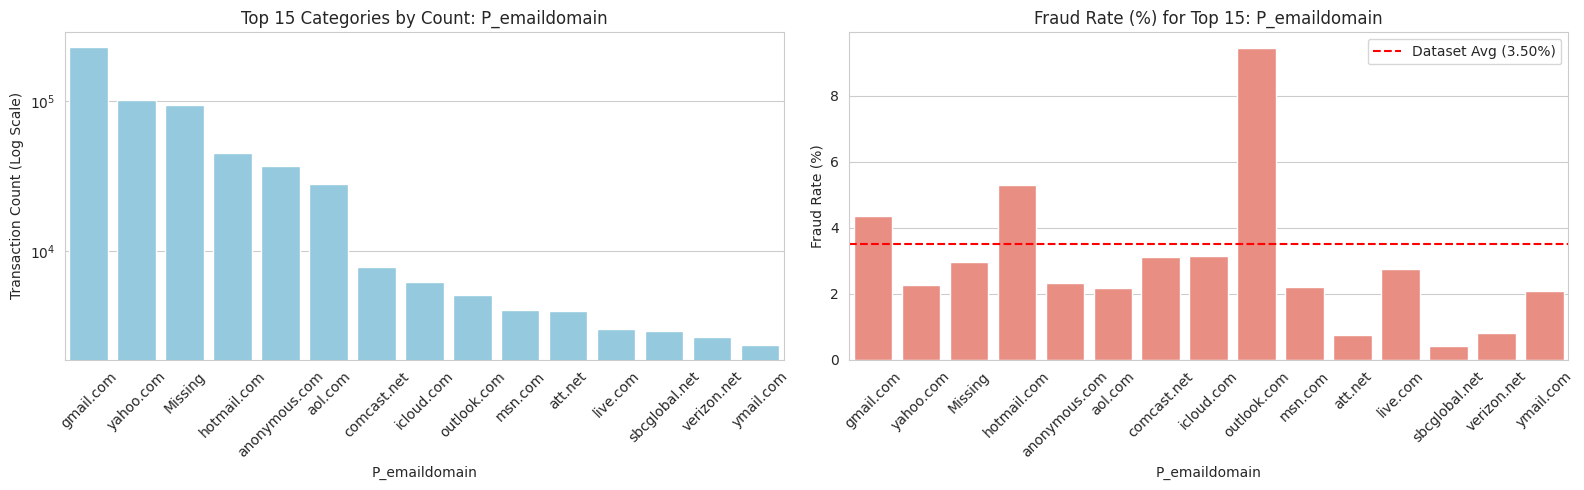

In [36]:
# ── Purchaser Email Domain Analysis ──
print("=== Purchaser Email Domain (P_emaildomain) ===")
plot_categorical_feature(train, 'P_emaildomain', top_n=15)

=== Recipient Email Domain (R_emaildomain) ===


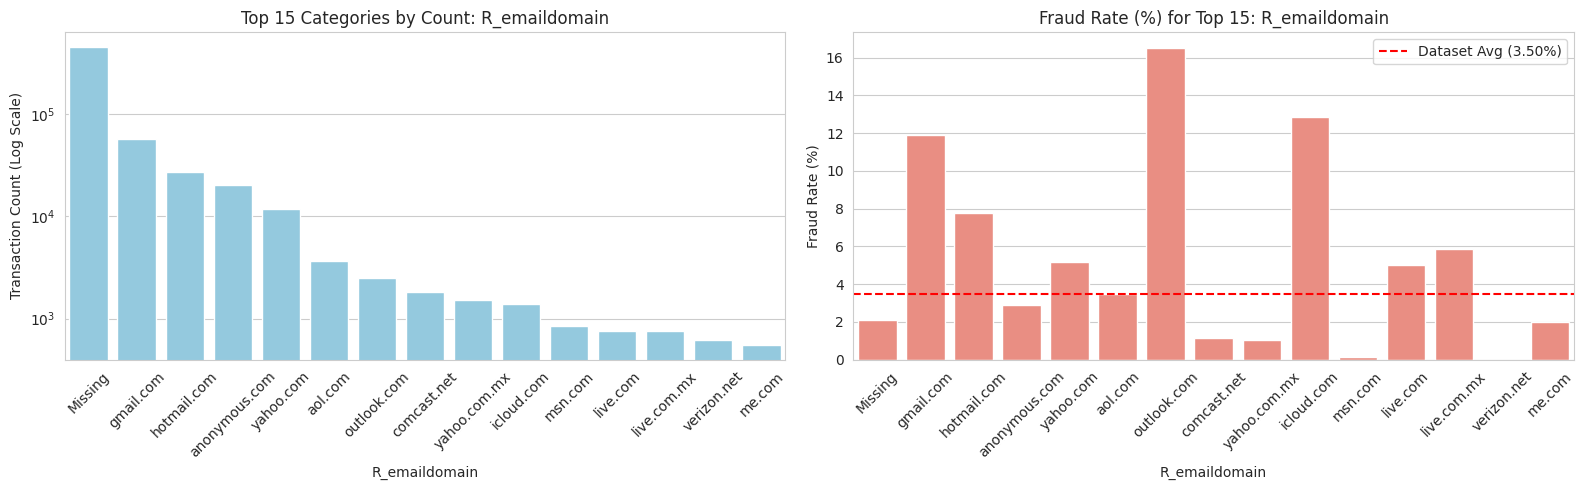

In [37]:
# ── Recipient Email Domain Analysis ──
print("=== Recipient Email Domain (R_emaildomain) ===")
plot_categorical_feature(train, 'R_emaildomain', top_n=15)

=== Device Type (DeviceType) ===


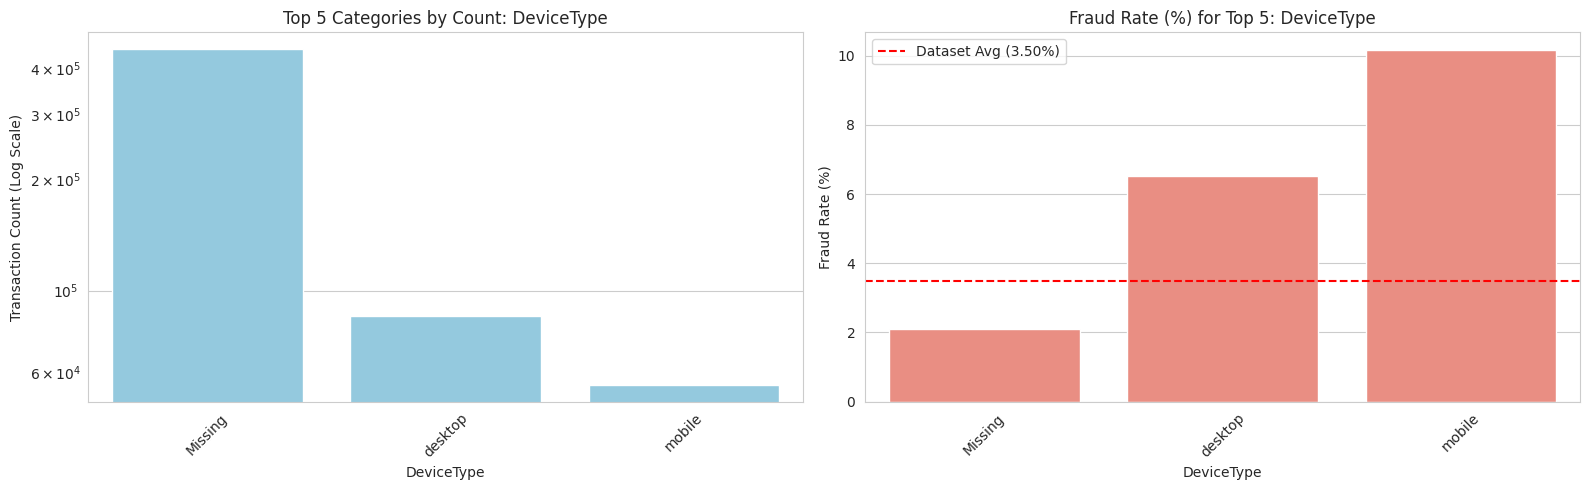

In [38]:
# ── Device Type Analysis ──
print("=== Device Type (DeviceType) ===")
plot_categorical_feature(train, 'DeviceType', top_n=5)

=== Device Info (DeviceInfo) ===


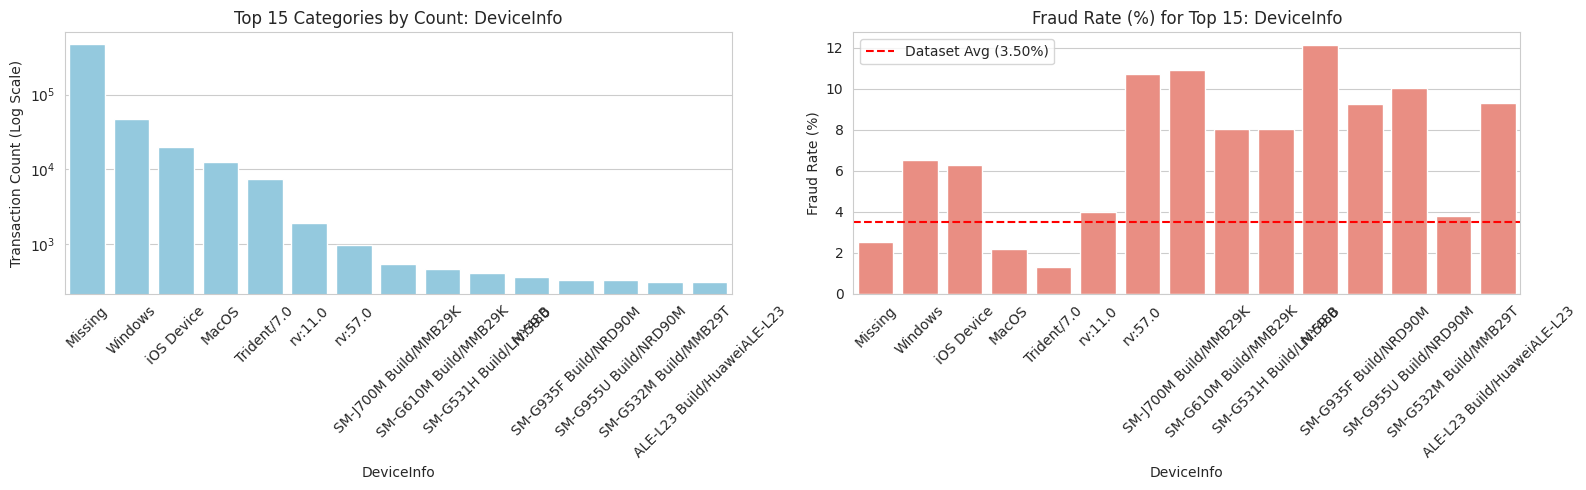

In [39]:
# ── Device Info Analysis ──
print("=== Device Info (DeviceInfo) ===")
plot_categorical_feature(train, 'DeviceInfo', top_n=15)

In [40]:
# ── List Categorical Identity Features ──
id_cat_cols = [f'id_{i}' for i in range(12, 39) if f'id_{i}' in train.columns]

id_summary = pd.DataFrame({
    'Column': id_cat_cols,
    'Dtype': train[id_cat_cols].dtypes.values,
    'Missing_Pct': (train[id_cat_cols].isnull().sum() / len(train) * 100).values,
    'Unique_Values': train[id_cat_cols].nunique(dropna=False).values
}).sort_values(by='Missing_Pct')

display(id_summary)

,Column,Dtype,Missing_Pct,Unique_Values
0,id_12,object,75.576083,3
3,id_15,object,76.126088,4
26,id_38,object,76.126088,3
23,id_35,object,76.126088,3
24,id_36,object,76.126088,3
25,id_37,object,76.126088,3
16,id_28,object,76.127273,3
17,id_29,object,76.127273,3
19,id_31,object,76.245132,131
5,id_17,float64,76.399736,105


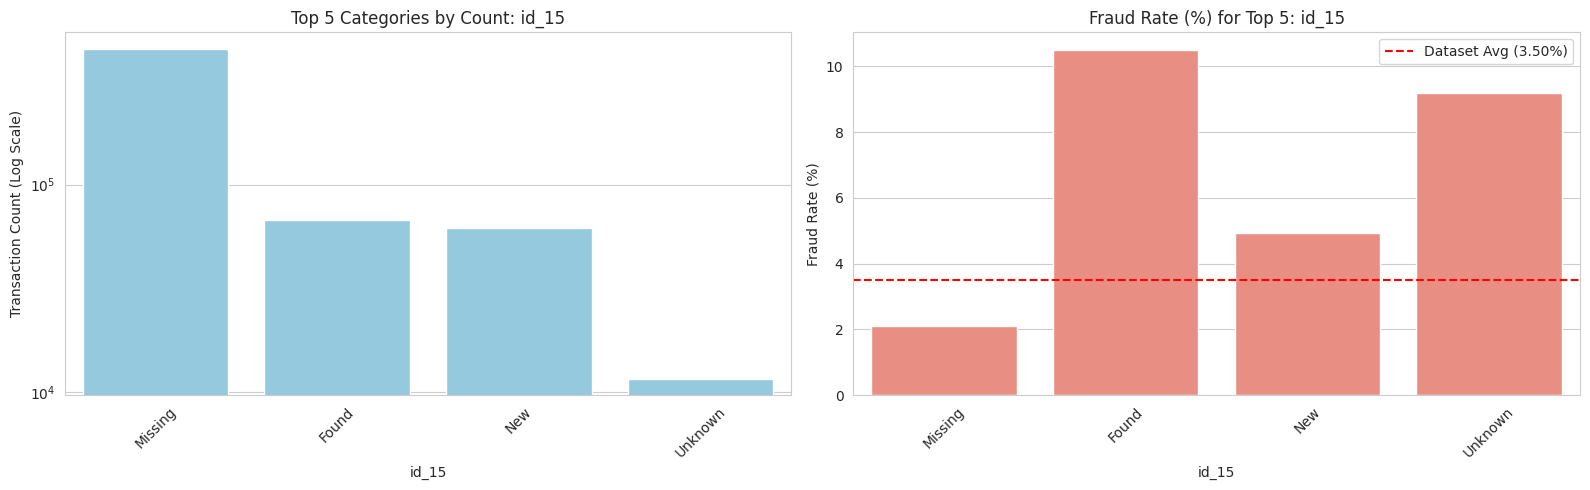

In [41]:
# ── Analyze id_15 (e.g., Found / New / Unknown) ──
plot_categorical_feature(train, 'id_15', top_n=5)

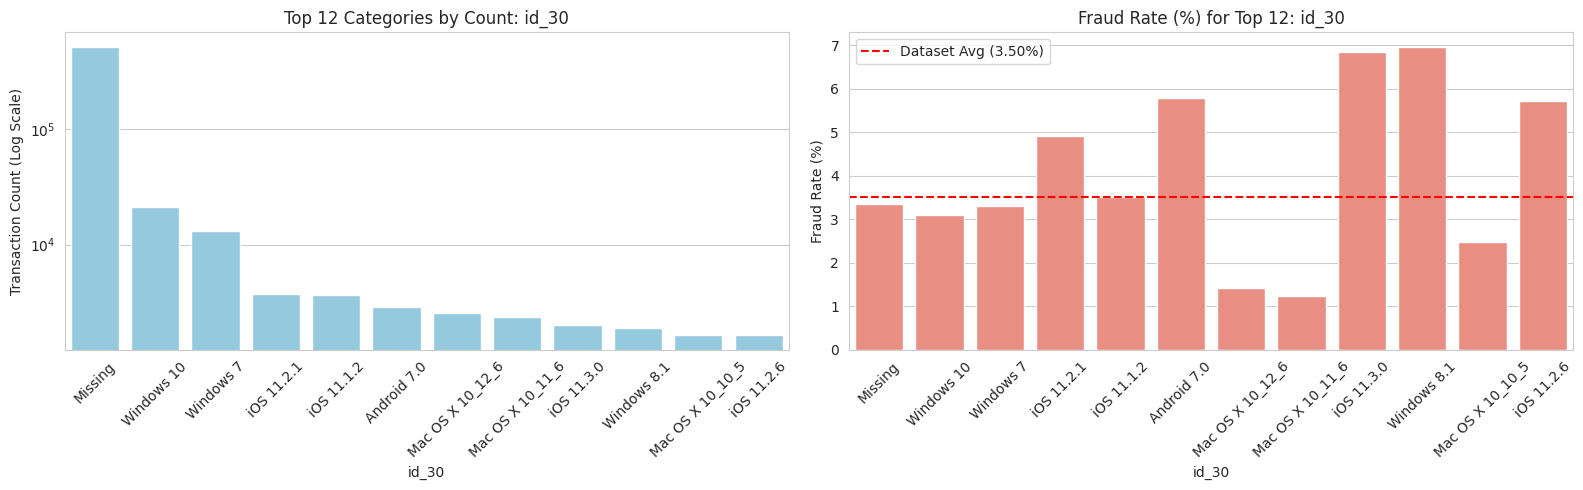

In [42]:
# ── Analyze id_30 (Operating System details) ──
plot_categorical_feature(train, 'id_30', top_n=12)

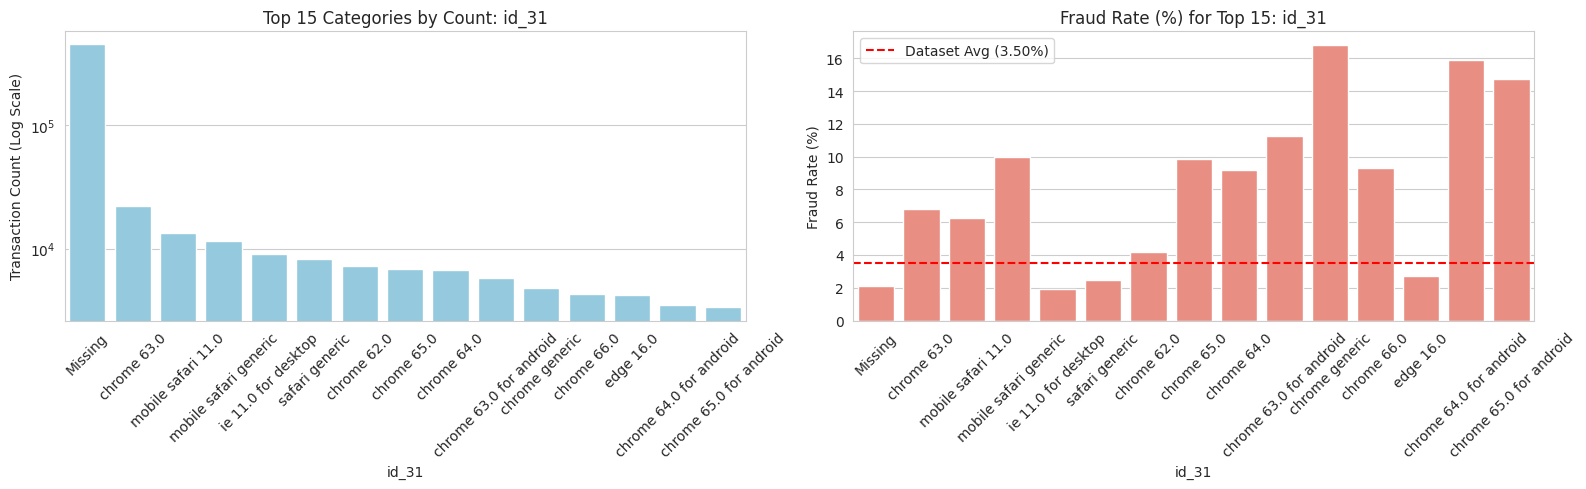

In [43]:
# ── Analyze id_31 (Browser Client) ──
plot_categorical_feature(train, 'id_31', top_n=15)

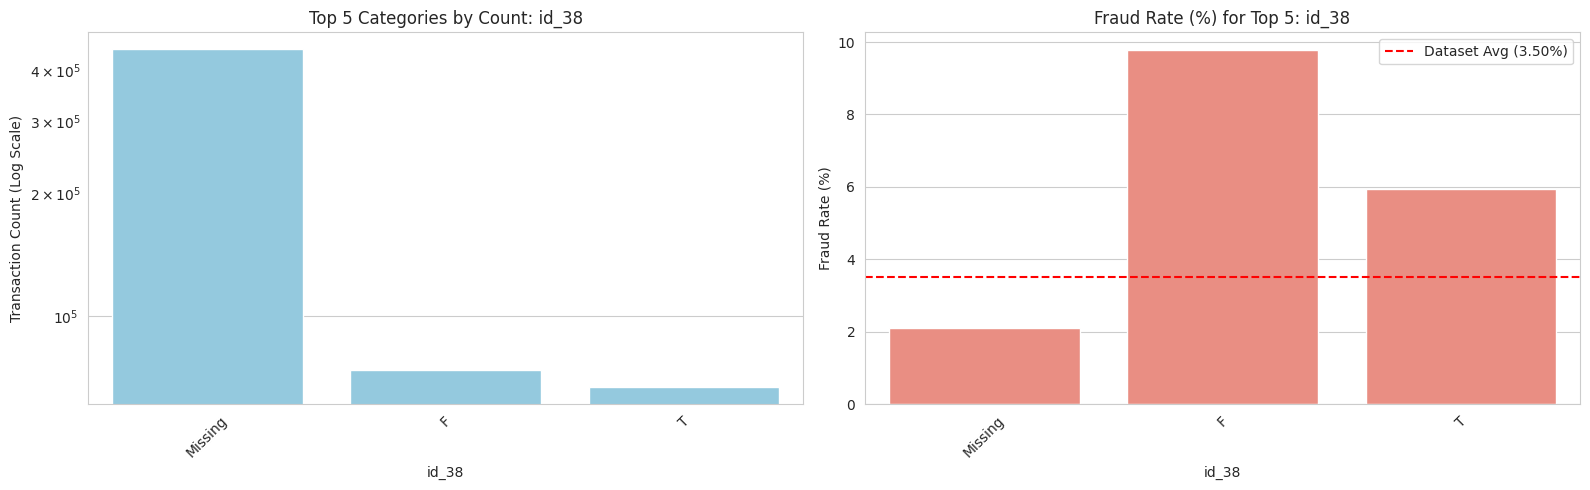

In [44]:
# ── Analyze id_38 (Binary / Status flag) ──
plot_categorical_feature(train, 'id_38', top_n=5)

# Feature Groups

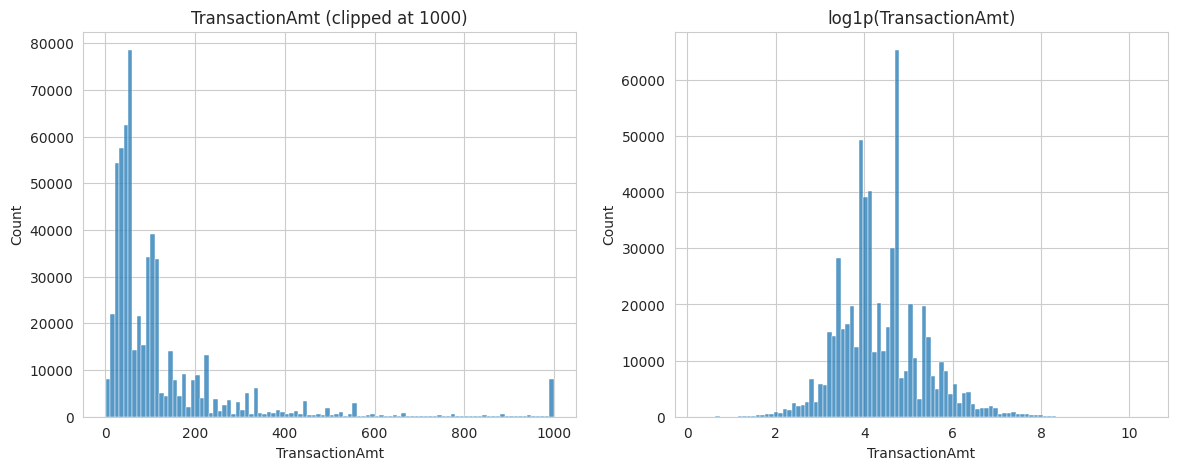

In [10]:
# ── TransactionAmt distribution ──
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.histplot(train['TransactionAmt'].clip(upper=1000), bins=100, ax=axes[0])
axes[0].set_title('TransactionAmt (clipped at 1000)')

sns.histplot(np.log1p(train['TransactionAmt']), bins=100, ax=axes[1])
axes[1].set_title('log1p(TransactionAmt)')
plt.show()

*The natural logarithm of (1+x)*, written as **ln(1+x)** or **log1p(x)** in data science libraries, is a powerful mathematical transformation used to stabilize variance, normalize skewed distributions, and handle zero values in a dataset.

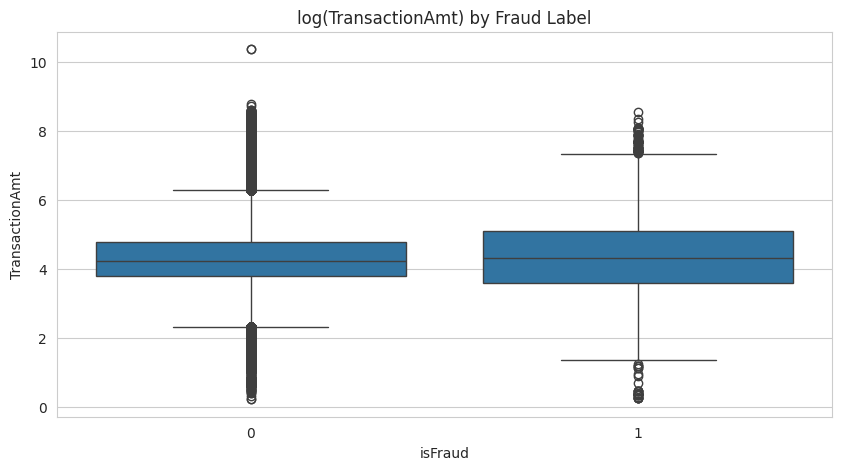

In [11]:
# ── TransactionAmt vs fraud ──
plt.figure(figsize=(10,5))
sns.boxplot(x='isFraud', y=np.log1p(train['TransactionAmt']), data=train)
plt.title('log(TransactionAmt) by Fraud Label')
plt.show()

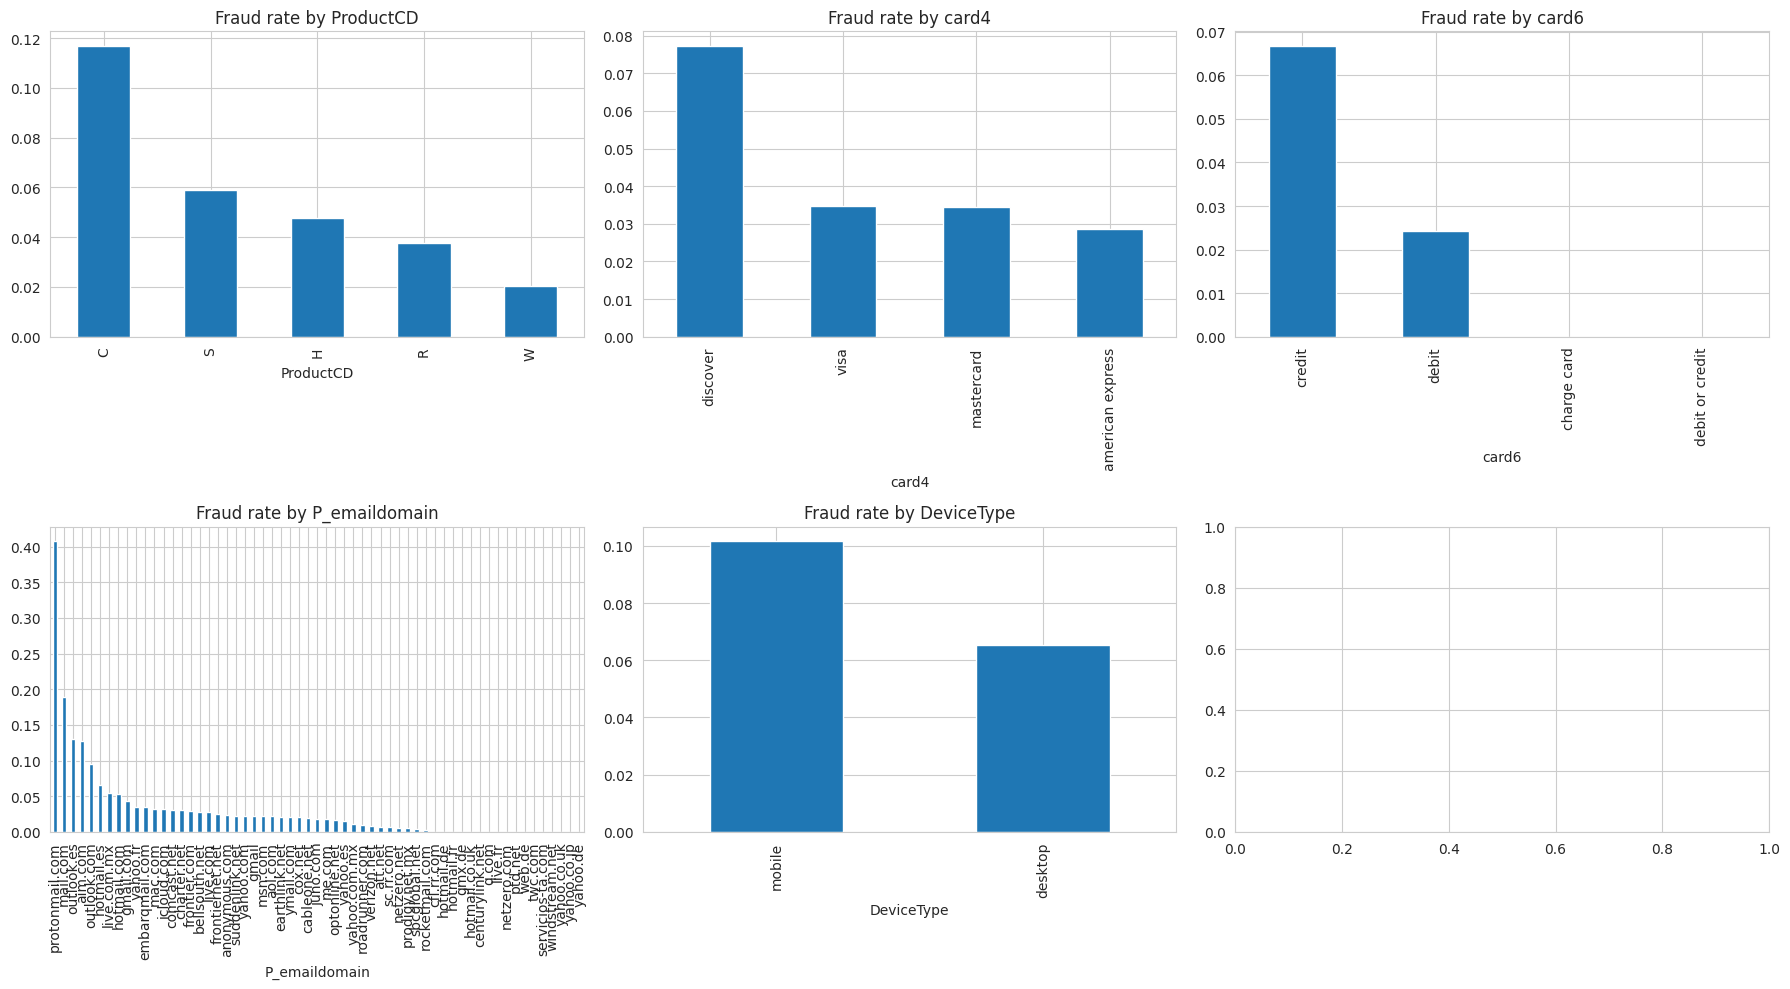

In [12]:
# ── Fraud rate by categorical features ──
cat_features = ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'DeviceType']

fig, axes = plt.subplots(2, 3, figsize=(18,10))
for ax, col in zip(axes.flat, cat_features):
    rate = train.groupby(col)['isFraud'].mean().sort_values(ascending=False)
    rate.plot(kind='bar', ax=ax)
    ax.set_title(f'Fraud rate by {col}')
plt.tight_layout()
plt.show()

86400 15811131
181.99920138888888 days covered


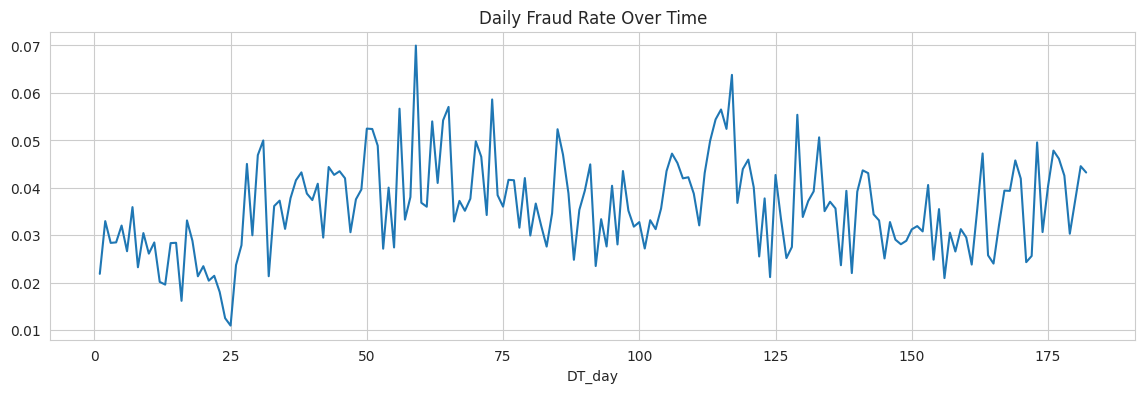

In [13]:
# ── TransactionDT — time structure ──
# TransactionDT is seconds from a reference point, not a real timestamp
print(train['TransactionDT'].min(), train['TransactionDT'].max())
print((train['TransactionDT'].max() - train['TransactionDT'].min()) / (3600*24), "days covered")

train['DT_day'] = train['TransactionDT'] // (3600*24)
daily_fraud = train.groupby('DT_day')['isFraud'].mean()
daily_fraud.plot(figsize=(14,4), title='Daily Fraud Rate Over Time')
plt.show()

# References
* https://medium.com/data-science/a-data-scientists-essential-guide-to-exploratory-data-analysis-25637eee0cf6$0
* https://towardsdatascience.com/data-quality-issues-that-kill-your-machine-learning-models-961591340b40/$0
* https://keras.io/examples/structured_data/imbalanced_classification/$0